In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score


 1. Carregamento dos dados

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Projetos Ciência de dados/Telco Customer Churn /WA_Fn-UseC_-Telco-Customer-Churn.csv')


2. Limpeza e Pré-processamento

In [5]:
# Removendo ID do cliente (não tem poder preditivo)
df.drop('customerID', axis=1, inplace=True)

In [6]:
# Tratando TotalCharges: convertendo para numérico e removendo espaços vazios
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

3. Codificação de Variáveis (Encoding)

In [7]:
le = LabelEncoder()

In [8]:
# Aplicando Label Encoding em colunas binárias (Sim/Não)
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [9]:
# Aplicando One-Hot Encoding em variáveis com múltiplas categorias
df = pd.get_dummies(df)

4. Divisão dos Dados

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

5. Normalização (Scaling)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

6. Treinamento do Modelo (Random Forest)

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

 7. Avaliação do Modelo

In [13]:
y_pred = model.predict(X_test)

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

--- Matriz de Confusão ---
[[924 109]
 [197 177]]

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



8. Importância das Variáveis

In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\n--- Top 5 Variáveis Mais Importantes ---")
print(importances.sort_values(ascending=False).head(5))


--- Top 5 Variáveis Mais Importantes ---
TotalCharges               0.148869
tenure                     0.136132
MonthlyCharges             0.134347
Contract_Month-to-month    0.091323
TechSupport_No             0.037399
dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

1. Extraindo a importância das variáveis do modelo treinado


In [17]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

2. Ordenando as 10 principais variáveis

In [18]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

 3. Criando o gráfico

/tmp/ipykernel_1331/3427753066.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


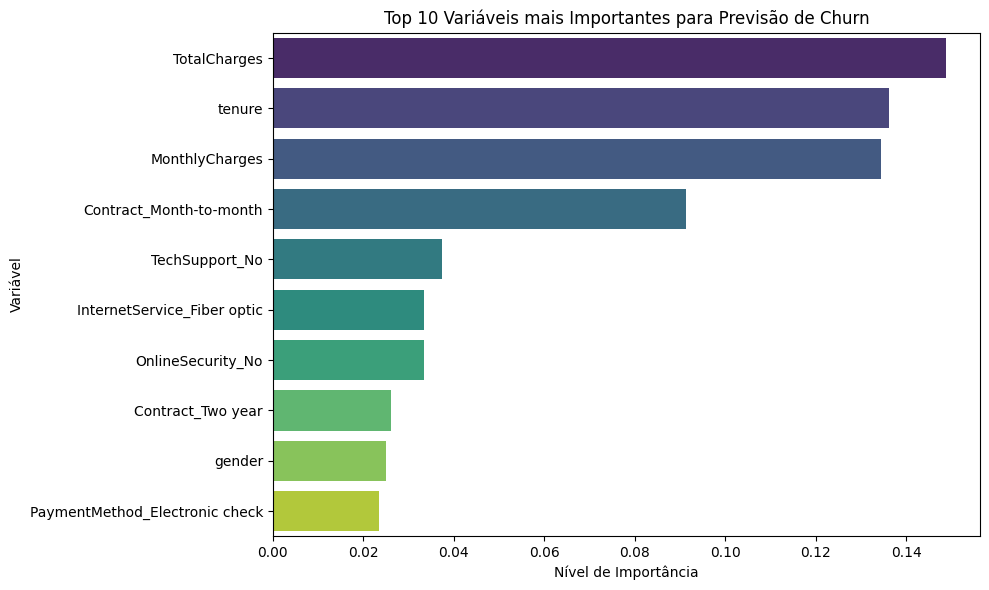

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Top 10 Variáveis mais Importantes para Previsão de Churn')
plt.xlabel('Nível de Importância')
plt.ylabel('Variável')
plt.tight_layout()